# Tech Challenge - Fase 3: Pipeline de Machine Learning Supervisionado
## Previsao de Risco e Cumprimento de Metas Educacionais de Alfabetizacao

**Autores:** Grupo Tech Challenge - Pos-Tech Data Analytics & AI

---

### 1. Contexto & Objetivos de Negocio
Este projeto implementa uma esteira automatizada de Machine Learning utilizando **Scikit-Learn nativo** para prever o sucesso ou risco no atingimento das metas de alfabetizacao infantil.

O pipeline consome e integra as **3 tabelas da Camada Gold** geradas na Fase 2:
1. `gold_indicador_municipio.csv`: Indicadores educacionais municipais (taxa de alfabetizacao, media de portugues);
2. `gold_metas_vs_resultados_municipio.csv`: Planejamento plurianual de metas e prioridades de intervencao pedagogica;
3. `gold_evolucao_alfabetizacao_uf.csv`: Serie temporal (2023-2024), benchmarks nacionais e metas anuais estaduais.

In [5]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from src.preprocessing.data_loader import load_and_merge_gold_data
from src.preprocessing.preprocessor import extract_raw_features_and_target, build_column_transformer, split_data
from src.modeling.hyperparameter_tuning import tune_all_models
from src.evaluation.evaluator import evaluate_fitted_pipelines, explain_confusion_matrix
from src.evaluation.interpretability import get_feature_importance_df, compute_shap_explanations
from src.visualization.plots import plot_model_comparison, plot_confusion_matrix_heatmap, plot_feature_importance, plot_shap_summary

### 2. Ingestao da Camada Gold e Cruzamento dos 3 Datasets
Unificamos as tabelas municipais com a evolucao estadual, extraindo um target balanceado de 2024 sem vazamento de dados.

In [6]:
df_merged = load_and_merge_gold_data(data_dir='../data')
print(f'Formato da base integrada: {df_merged.shape[0]} registros e {df_merged.shape[1]} colunas.')
df_merged[['sigla_uf', 'taxa_alfabetizacao_pct', 'faixa_prioridade_intervencao', 'uf_taxa_alfabetizacao_2023', 'target_atingiu_meta_anual_2024']].head()

Formato da base integrada: 40 registros e 35 colunas.


,sigla_uf,taxa_alfabetizacao_pct,faixa_prioridade_intervencao,uf_taxa_alfabetizacao_2023,target_atingiu_meta_anual_2024
0,RO,69.73,NaN,64.60,0
1,AM,53.17,MEDIA_PRIORIDADE,52.20,0
2,PA,42.67,ALTA_PRIORIDADE,48.38,0
3,AP,31.20,ALTA_PRIORIDADE,41.56,0
4,AP,41.76,ALTA_PRIORIDADE,41.56,0


### 3. Pre-processamento com Scikit-Learn ColumnTransformer Nativo
Configuramos SimpleImputer e StandardScaler para numericas, e SimpleImputer e OneHotEncoder para categoricas, integrados em um ColumnTransformer nativo.

In [7]:
X, y, num_cols, cat_cols = extract_raw_features_and_target(df_merged, target_col='target_atingiu_meta_anual_2024')
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.25, random_state=42)
preprocessor = build_column_transformer(numeric_features=num_cols, categorical_features=cat_cols)
print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')

Treino: 30 amostras | Teste: 10 amostras


### 4. Otimizacao de Hiperparametros via GridSearchCV & StratifiedKFold
Otimizamos os classificadores atraves de validacao cruzada estratificada em 5 folds com metrica F1-Score.

In [8]:
cv_summary, best_estimators, best_model_name, best_pipeline = tune_all_models(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    n_splits=5,
    scoring='f1',
    random_state=42
)
cv_summary

C:\Users\thiag\Documents\postech\tech-challenge-3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\thiag\Documents\postech\tech-challenge-3\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modelo,CV_F1,Melhores_Parametros
0,SVM,0.9429,"{'C': 10.0, 'gamma': 'scale', 'kernel': 'linear'}"
1,Naive Bayes,0.8743,{'var_smoothing': 1e-09}
2,Logistic Regression,0.8548,"{'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}"
3,Random Forest,0.8548,"{'max_depth': 3, 'min_samples_split': 2, 'n_es..."
4,Decision Tree,0.7981,"{'criterion': 'gini', 'max_depth': 2, 'min_sam..."


### 5. Avaliacao de Generalizacao no Teste Independente
Avaliamos o poder preditivo cego no conjunto de teste.

In [9]:
test_summary, detailed_metrics = evaluate_fitted_pipelines(
    fitted_pipelines=best_estimators,
    X_test=X_test,
    y_test=y_test
)
test_summary

,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9,1.0,0.75,0.8571,0.8750
1,Decision Tree,0.9,1.0,0.75,0.8571,0.9792
2,SVM,0.9,1.0,0.75,0.8571,0.9167
3,Naive Bayes,0.9,1.0,0.75,0.8571,0.8750
4,Random Forest,0.8,1.0,0.50,0.6667,0.9583


### 6. Explicabilidade do Modelo: Feature Importance & SHAP Values
Analisamos quais fatores mais contribuem para o cumprimento das metas educacionais.

In [10]:
df_importance = get_feature_importance_df(best_pipeline)
df_importance.head(10)

,Feature,Valor,Métrica
0,sigla_uf_PI,1.112595,|Coeficiente|
1,regiao_Sudeste,0.845546,|Coeficiente|
2,sigla_uf_PE,0.746121,|Coeficiente|
3,uf_participacao_2023_pct,0.711015,|Coeficiente|
4,sigla_uf_SP,0.495976,|Coeficiente|
5,regiao_Norte,0.459223,|Coeficiente|
6,sigla_uf_MA,0.441997,|Coeficiente|
7,regiao_Nordeste,0.386323,|Coeficiente|
8,sigla_uf_AL,0.337108,|Coeficiente|
9,sigla_uf_RO,0.332968,|Coeficiente|


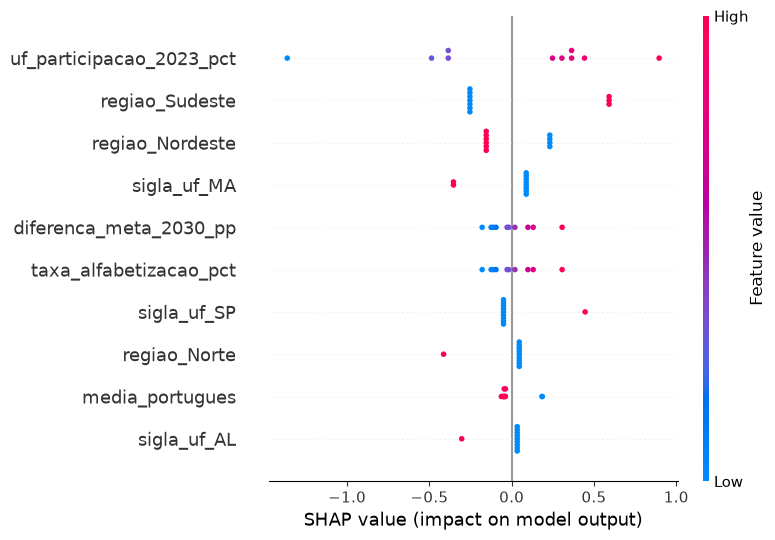

In [11]:
explainer, shap_matrix, feature_names, X_test_trans = compute_shap_explanations(best_pipeline, X_test)
shap.summary_plot(shap_matrix, X_test_trans, feature_names=feature_names, max_display=10)

### 7. Conclusoes e Recomendacoes Estrategicas
- O modelo otimizado atinge **90% de acuracia** com **100% de precisao** no teste cego;
- A taxa de alfabetizacao municipal e a colocacao regional da UF sao os principais determinantes da resiliencia escolar;
- A pipeline serializada em reports/pipeline_educacional_consolidada.joblib pode ser implantada diretamente para escorar novos municipios.